# Phase 3B — RCM Level-1 validation Pilot

Authoritative record for the five-scene Pilot. It does not change Phase 4, Phase 5, or the Dashboard.


## 1. Scope, status, and scientific boundaries

Level-1 is evaluated as an open-water-oriented candidate workflow. EGS is reference/validation only; the fixed class-1 geometry is semantic permanent-water reference, never normal or pre-event hydrology.


In [20]:
from pathlib import Path
import json, sys
import numpy as np
import pandas as pd
ROOT = Path.cwd()
while not (ROOT / 'analysis').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
OUT = ROOT / 'data/processed/phase3b'
pd.set_option('display.max_columns', 100)


## 2. Environment, SNAP preflight, and reproducibility

Use `conda activate space-hackathon-2026` and `export SNAP_GPT=/Applications/esa-snap/bin/gpt`. The commands below replay only local cached data and SNAP products.


In [21]:
from analysis.rcm_preprocessing import CommonGrid, find_snap_gpt, snap_diagnostics, snap_operator_check
grid = CommonGrid()
print(find_snap_gpt())
print(snap_diagnostics()['diagnostics'].splitlines()[:5])
snap_operator_check()


/Applications/esa-snap/bin/gpt
['SNAP Release version 14.0.0', 'SNAP home: /Applications/esa-snap/bin/..', 'SNAP debug: null', 'SNAP log level: null', 'Java home: /Applications/esa-snap/.install4j/jre.bundle/Contents/Home']


{'path': '/Applications/esa-snap/bin/gpt',
 'operators': {'Calibration': True,
  'Terrain-Correction': True,
  'RCM input format': True},
 'all_present': True,
 'help_returncode': 0,
 'iformat_returncode': 0}

## 3. Level-1 inventory and checksum audit


In [22]:
inventory = pd.read_csv(OUT / 'level1_inventory.csv')
display(inventory[['observation_id','timestamp_utc','beam_mode','mode_group','polarizations','vendor_checksum_verified']])


,observation_id,timestamp_utc,beam_mode,mode_group,polarizations,vendor_checksum_verified
0,20251213T141623Z,2025-12-13T14:16:23.964000Z,16M16,stripmap16_desc,HH HV,True
1,20251214T014240Z,2025-12-14T01:42:40.271000Z,SC30MA,scansar30_asc,HH HV,True
2,20251214T142421Z,2025-12-14T14:24:21.125000Z,16M9,stripmap16_desc,HH HV,True
3,20251215T015036Z,2025-12-15T01:50:36.880000Z,SC30MB,scansar30_asc,HH HV,True
4,20251217T141634Z,2025-12-17T14:16:34.885000Z,16M16,stripmap16_desc,HH HV,True
5,20251218T014217Z,2025-12-18T01:42:17.706000Z,SC30MA,scansar30_asc,HH HV,True
6,20251218T142431Z,2025-12-18T14:24:31.822000Z,16M9,stripmap16_desc,HH HV,True
7,20251219T015011Z,2025-12-19T01:50:11.416000Z,SC30MB,scansar30_asc,HH HV,True
8,20251221T141646Z,2025-12-21T14:16:46.218000Z,16M16,stripmap16_desc,HH HV,True
9,20251222T014227Z,2025-12-22T01:42:27.846000Z,SC30MA,scansar30_asc,HH HV,True


## 4. Pilot selection and EGS pairing


In [23]:
pilot = inventory[inventory.pilot_id.notna()].copy()
display(pilot[['pilot_id','observation_id','timestamp_utc','beam_mode','mode_group','egs_observation_id']])


,pilot_id,observation_id,timestamp_utc,beam_mode,mode_group,egs_observation_id
2,P01,20251214T142421Z,2025-12-14T14:24:21.125000Z,16M9,stripmap16_desc,OBS02
3,P02,20251215T015036Z,2025-12-15T01:50:36.880000Z,SC30MB,scansar30_asc,OBS03
4,P03,20251217T141634Z,2025-12-17T14:16:34.885000Z,16M16,stripmap16_desc,OBS05
7,P04,20251219T015011Z,2025-12-19T01:50:11.416000Z,SC30MB,scansar30_asc,OBS06
8,P05,20251221T141646Z,2025-12-21T14:16:46.218000Z,16M16,stripmap16_desc,OBS07


## 5. Fixed common-grid contract


In [24]:
display(pd.Series(json.loads((OUT / 'common_grid.json').read_text())))


crs                                                     EPSG:32610
left                                                      563960.0
bottom                                                   5443240.0
right                                                     569960.0
top                                                      5449240.0
resolution                                                    30.0
width                                                          200
height                                                         200
bounds                  [563960.0, 5443240.0, 569960.0, 5449240.0]
transform        [30.0, 0.0, 563960.0, 0.0, -30.0, 5449240.0, 0...
pixel_area_ha                                                 0.09
dtype: object

## 6. SNAP calibration and terrain-correction provenance

The local graph applies Calibration, buffered AOI subset, Range-Doppler Terrain Correction with Copernicus 30 m DEM, then Python linear-power aggregation to the fixed grid.


In [25]:
display(pd.read_csv(OUT / 'observation_qa.csv'))
display(pd.Series(json.loads((OUT / 'dem_provenance.json').read_text())))


,observation_id,timestamp_utc,beam_mode,mode_group,valid_pixels,valid_pct,geometry_status,noise_floor_status_hh,noise_floor_status_hv,calibration_status,calibration_representation,classification_method_version,validation_status,comparability_category,warnings
0,20251214T142421Z,2025-12-14T14:24:21.125000Z,16M9,stripmap16_desc,40000,100.0,pass,not_required_for_pilot,available,bands_present,Gamma0+Sigma0,pending,pilot_preprocessed,direct_egs_overlap,formal LUT and shoreline-offset QA pending
1,20251215T015036Z,2025-12-15T01:50:36.880000Z,SC30MB,scansar30_asc,40000,100.0,pass,not_required_for_pilot,available,bands_present,Gamma0+Sigma0,pending,pilot_preprocessed,direct_egs_overlap,formal LUT and shoreline-offset QA pending
2,20251217T141634Z,2025-12-17T14:16:34.885000Z,16M16,stripmap16_desc,40000,100.0,pass,not_required_for_pilot,available,bands_present,Gamma0+Sigma0,pending,pilot_preprocessed,direct_egs_overlap,formal LUT and shoreline-offset QA pending
3,20251219T015011Z,2025-12-19T01:50:11.416000Z,SC30MB,scansar30_asc,40000,100.0,pass,not_required_for_pilot,available,bands_present,Gamma0+Sigma0,pending,pilot_preprocessed,direct_egs_overlap,formal LUT and shoreline-offset QA pending
4,20251221T141646Z,2025-12-21T14:16:46.218000Z,16M16,stripmap16_desc,40000,100.0,pass,not_required_for_pilot,available,bands_present,Gamma0+Sigma0,pending,pilot_preprocessed,direct_egs_overlap,formal LUT and shoreline-offset QA pending


source                           ESA SNAP Copernicus 30m Global DEM
snap_dem_cache    /Users/josephdum5pro/.snap/auxdata/dem/Coperni...
tiles             [{'path': '/Users/josephdum5pro/.snap/auxdata/...
created_utc                        2026-10-04T06:51:54.757828+00:00
dtype: object

## 7. Calibration LUT cross-check

Native SNAP Sigma0 is compared against the vendor stepwise LUT relation `(DN² + offset) / gain`; Gamma0 is separately materialized from SNAP's documented virtual expression.


In [26]:
display(pd.read_csv(OUT / 'calibration_lut_qa.csv'))


,observation_id,beam_mode,sample,row,col,dn,expected_sigma_power,snap_sigma_power,sigma_relative_error,expected_gamma_power,snap_gamma_power,gamma_relative_error,pass_native_sigma_1e-5
0,20251214T142421Z,16M9,1,3620,1668,611.0,0.022479,0.022479,1.708501e-08,0.027485,0.027485,0.000018,True
1,20251214T142421Z,16M9,2,5430,2502,1183.0,0.084675,0.084675,2.915987e-08,0.103041,0.103039,0.000019,True
2,20251214T142421Z,16M9,3,7240,3336,2509.0,0.382713,0.382713,1.739369e-08,0.463529,0.463519,0.000023,True
3,20251215T015036Z,SC30MB,1,2423,3428,2005.0,0.257411,0.257411,2.531047e-08,0.296018,0.296085,0.000225,True
4,20251215T015036Z,SC30MB,2,3635,5143,1655.0,0.172259,0.172259,1.783153e-08,0.201680,0.201731,0.000253,True
5,20251215T015036Z,SC30MB,3,4846,6857,818.0,0.041305,0.041305,2.568880e-08,0.049267,0.049279,0.000225,True


## 8. HH/HV and Gamma0/Sigma0 value distributions


In [27]:
dist = pd.read_csv(OUT / 'calibrated_value_distributions.csv')
display(dist)


,observation_id,beam_mode,mode_group,representation,polarization,units,count,p1,p5,median,p95,p99,min,max
0,20251214T142421Z,16M9,stripmap16_desc,Gamma,HH,linear_power,40000,0.005222,0.007237,0.163662,0.484747,1.067647,0.002414,53.903614
1,20251214T142421Z,16M9,stripmap16_desc,Gamma,HH,dB,40000,-22.821689,-21.404549,-7.860520,-3.144849,0.284275,-26.172073,17.316179
2,20251214T142421Z,16M9,stripmap16_desc,Gamma,HV,linear_power,40000,0.001432,0.001858,0.031197,0.101511,0.204296,0.000895,5.369442
3,20251214T142421Z,16M9,stripmap16_desc,Gamma,HV,dB,40000,-28.440221,-27.309592,-15.058916,-9.934860,-6.897403,-30.479795,7.299292
4,20251214T142421Z,16M9,stripmap16_desc,Sigma,HH,linear_power,40000,0.004284,0.005934,0.134329,0.398071,0.874143,0.001981,44.301929
5,20251214T142421Z,16M9,stripmap16_desc,Sigma,HH,dB,40000,-23.681067,-22.266186,-8.718311,-4.000399,-0.584176,-27.031775,16.464226
6,20251214T142421Z,16M9,stripmap16_desc,Sigma,HV,linear_power,40000,0.001174,0.001525,0.025584,0.083313,0.167589,0.000736,4.415865
7,20251214T142421Z,16M9,stripmap16_desc,Sigma,HV,dB,40000,-29.303633,-28.168706,-15.920308,-10.792895,-7.757546,-31.329304,6.450158
8,20251215T015036Z,SC30MB,scansar30_asc,Gamma,HH,linear_power,40000,0.005527,0.008438,0.187833,0.586882,1.582161,0.002483,107.418839
9,20251215T015036Z,SC30MB,scansar30_asc,Gamma,HH,dB,40000,-22.574940,-20.737412,-7.262288,-2.314495,1.992507,-26.050642,20.310804


## 9. Grid geometry, coverage, and valid-mask QA

Each Pilot grid preserves the complete 200×200 AOI; validity requires at least 95% source coverage.


In [28]:
display(pd.read_csv(OUT / 'mask_area_audit.csv').query("mask == 'valid'"))


,observation_id,mask,pixels,area_ha,fraction_of_valid_pct
0,20251214T142421Z,valid,40000,3600.0,100.0
6,20251215T015036Z,valid,40000,3600.0,100.0
12,20251217T141634Z,valid,40000,3600.0,100.0
18,20251219T015011Z,valid,40000,3600.0,100.0
24,20251221T141646Z,valid,40000,3600.0,100.0


## 10. Fixed semantic permanent-water reference


In [29]:
reference_audit = json.loads((OUT / 'reference_rasterization_audit.json').read_text())
display(pd.Series(reference_audit['permanent_reference']))


path          /Users/josephdum5pro/Documents/Dalhousie Unive...
source_crs                          urn:ogc:def:crs:EPSG::32610
pixels                                                    10829
area_ha                                                  974.61
semantic      fixed EGS semantic permanent-water reference; ...
dtype: object

## 11. Date-specific EGS class-2 reference and rasterization QA


In [30]:
display(pd.DataFrame(reference_audit['egs_open_water_frames']['per_observation']).T)
print(reference_audit['alignment_note'])


,egs_observation_id,pixels,area_ha
20251214T142421Z,OBS02,213,19.17
20251215T015036Z,OBS03,563,50.67
20251217T141634Z,OBS05,414,37.26
20251219T015011Z,OBS06,323,29.07
20251221T141646Z,OBS07,228,20.52


Both Phase 4 reference GeoJSON files declare EPSG:32610, matching the fixed grid. Their semantic permanent-water geometry cannot be used as a same-date shoreline registration truth during a flood; a source-to-reference shoreline offset gate is therefore not claimed from this pilot.


## 12. Candidate classifier definitions

C0 is global HH, C1 is fixed mode-group HH, and C2 is fixed mode-group HH/HV with the registered HV noise rule. There are no date-specific thresholds.


In [31]:
display(pd.DataFrame(json.loads((OUT / 'method_candidates.json').read_text())['definitions']))


,candidate_id,description,use_hv
0,C0_global_hh,one global Gamma0-HH threshold,False
1,C1_group_hh,one fixed HH threshold per mode group,False
2,C2_group_hh_hv,C1 plus a pooled group HV threshold where HV i...,True


## 13. Threshold-unit and water-fraction audit


In [32]:
areas = pd.read_csv(OUT / 'mask_area_audit.csv')
display(areas[areas['mask'].str.contains('classified|candidate')])


,observation_id,mask,pixels,area_ha,fraction_of_valid_pct
3,20251214T142421Z,classified_water_before_semantic_subtraction,10597,953.73,26.4925
4,20251214T142421Z,candidate_flood_before_cleanup,1746,157.14,4.3650
5,20251214T142421Z,candidate_flood_after_cleanup,1392,125.28,3.4800
9,20251215T015036Z,classified_water_before_semantic_subtraction,9449,850.41,23.6225
10,20251215T015036Z,candidate_flood_before_cleanup,1163,104.67,2.9075
11,20251215T015036Z,candidate_flood_after_cleanup,949,85.41,2.3725
15,20251217T141634Z,classified_water_before_semantic_subtraction,21222,1909.98,53.0550
16,20251217T141634Z,candidate_flood_before_cleanup,10969,987.21,27.4225
17,20251217T141634Z,candidate_flood_after_cleanup,10779,970.11,26.9475
21,20251219T015011Z,classified_water_before_semantic_subtraction,10121,910.89,25.3025


## 14. Spatial diagnostics — stripmap Pilot


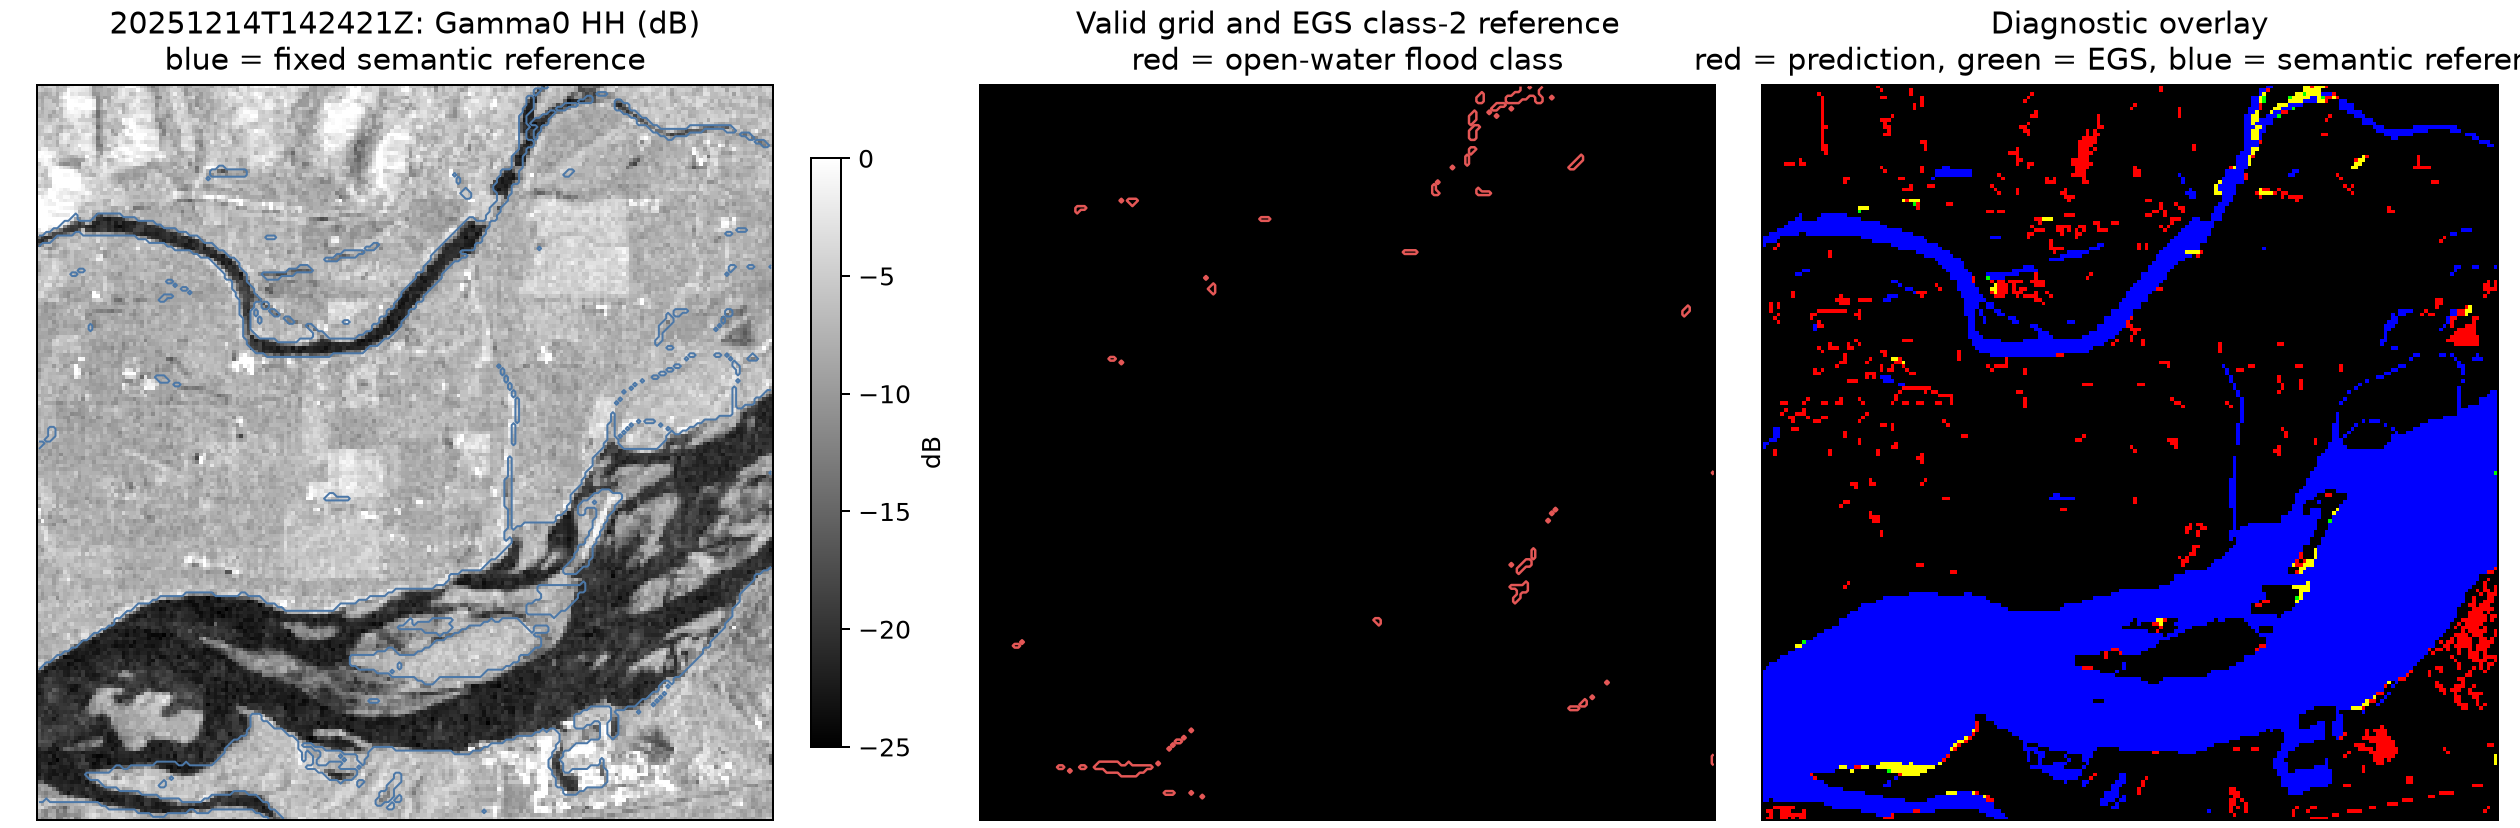

In [33]:
from IPython.display import Image, display
display(Image(filename=str(OUT / 'qa_figures/20251214T142421Z_diagnostic.png')))


## 15. Spatial diagnostics — ScanSAR Pilot


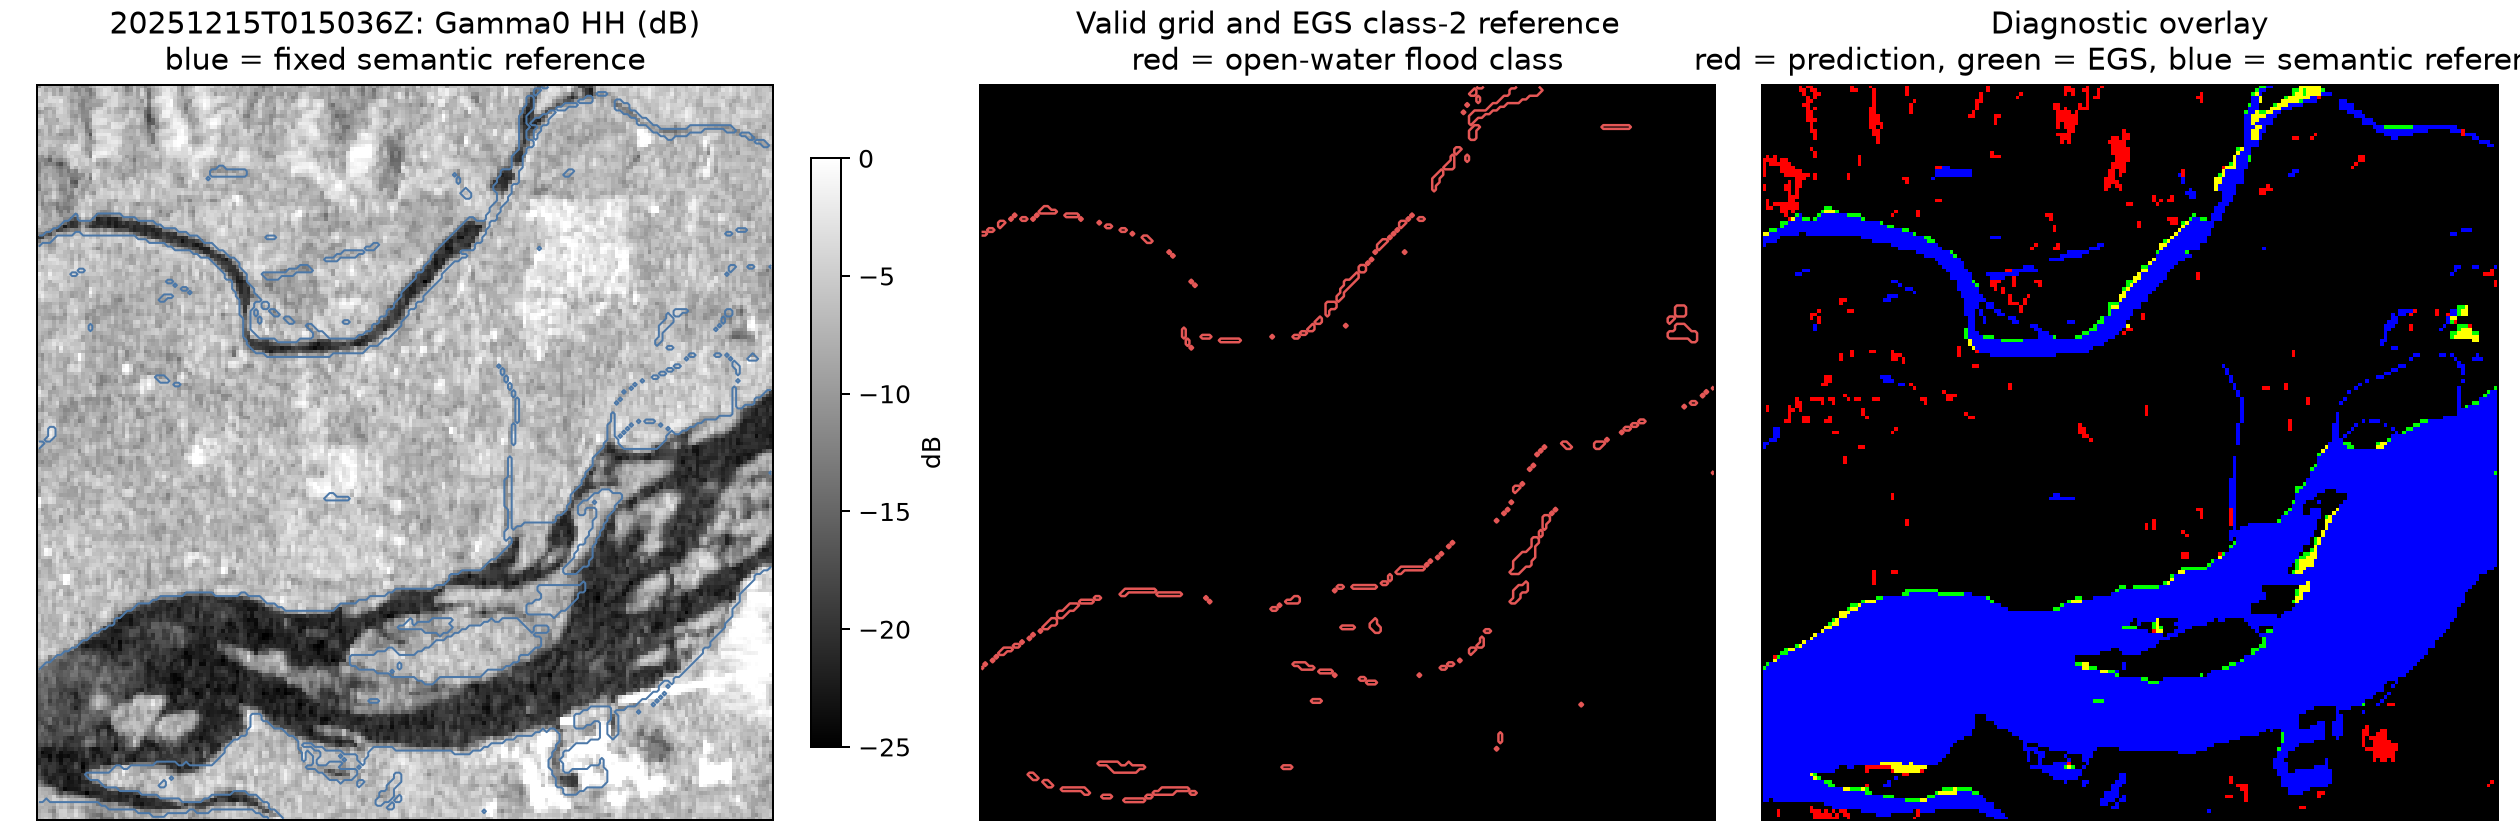

In [34]:
display(Image(filename=str(OUT / 'qa_figures/20251215T015036Z_diagnostic.png')))


## 16. Baseline LOODO validation


In [35]:
baseline = json.loads((OUT / 'validation_summary.json').read_text())
display(pd.DataFrame(baseline['candidate_summary']))
display(pd.read_csv(OUT / 'validation_metrics.csv'))


,candidate_id,representation,iou_median,f1_median,area_bias_abs_median
0,C0_global_hh,Gamma0,0.081479,0.150680,703.286385
1,C0_global_hh,Sigma0,0.108824,0.196286,553.521127
2,C1_group_hh,Gamma0,0.064667,0.121478,1394.685990
3,C1_group_hh,Sigma0,0.057322,0.108429,1482.043344
4,C2_group_hh_hv,Gamma0,0.119588,0.213629,693.236715
5,C2_group_hh_hv,Sigma0,0.098756,0.179760,866.908213


,tp_pixels,fp_pixels,fn_pixels,tn_pixels,precision,recall,f1,iou,predicted_area_ha,reference_area_ha,area_bias_ha,area_bias_pct,false_positive_area_ha,false_negative_area_ha,boundary_f1_30m,boundary_f1_60m,observation_id,fold_id,candidate_id,mode_group,representation,thresholds
0,200,1511,13,38276,0.116891,0.938967,0.207900,0.116009,153.99,19.17,134.82,703.286385,135.99,1.17,0.265891,0.299430,20251214T142421Z,LOODO_20251214T142421Z,C0_global_hh,stripmap16_desc,Gamma0,"{""global_hh"": -9.887617267668247}"
1,309,1246,254,38191,0.198714,0.548845,0.291785,0.170813,139.95,50.67,89.28,176.198934,112.14,22.86,0.342620,0.365269,20251215T015036Z,LOODO_20251215T015036Z,C0_global_hh,scansar30_asc,Gamma0,"{""global_hh"": -9.887617267668247}"
2,402,7524,12,32062,0.050719,0.971014,0.096403,0.050642,713.34,37.26,676.08,1814.492754,677.16,1.08,0.128497,0.163509,20251217T141634Z,LOODO_20251217T141634Z,C0_global_hh,stripmap16_desc,Gamma0,"{""global_hh"": -9.516837604343891}"
3,205,2193,118,37484,0.085488,0.634675,0.150680,0.081479,215.82,29.07,186.75,642.414861,197.37,10.62,0.175177,0.193277,20251219T015011Z,LOODO_20251219T015011Z,C0_global_hh,scansar30_asc,Gamma0,"{""global_hh"": -9.887617267668247}"
4,215,5240,13,34532,0.039413,0.942982,0.075664,0.039320,490.95,20.52,470.43,2292.543860,471.60,1.17,0.101116,0.125600,20251221T141646Z,LOODO_20251221T141646Z,C0_global_hh,stripmap16_desc,Gamma0,"{""global_hh"": -9.734139420092106}"
5,198,1063,15,38724,0.157018,0.929577,0.268657,0.155172,113.49,19.17,94.32,492.018779,95.67,1.35,0.329193,0.354240,20251214T142421Z,LOODO_20251214T142421Z,C1_group_hh,stripmap16_desc,Gamma0,"{""scansar30_asc_hh"": -9.100124400109053, ""stri..."
6,350,1991,213,37446,0.149509,0.621670,0.241047,0.137040,210.69,50.67,160.02,315.808171,179.19,19.17,0.285948,0.306061,20251215T015036Z,LOODO_20251215T015036Z,C1_group_hh,scansar30_asc,Gamma0,"{""scansar30_asc_hh"": -9.372846353799105, ""stri..."
7,401,5787,13,33799,0.064803,0.968599,0.121478,0.064667,556.92,37.26,519.66,1394.685990,520.83,1.17,0.154753,0.194065,20251217T141634Z,LOODO_20251217T141634Z,C1_group_hh,stripmap16_desc,Gamma0,"{""scansar30_asc_hh"": -9.100124400109053, ""stri..."
8,254,4888,69,34789,0.049397,0.786378,0.092955,0.048743,462.78,29.07,433.71,1491.950464,439.92,6.21,0.111953,0.134302,20251219T015011Z,LOODO_20251219T015011Z,C1_group_hh,scansar30_asc,Gamma0,"{""scansar30_asc_hh"": -8.961181309074163, ""stri..."
9,212,3774,16,35998,0.053186,0.929825,0.100617,0.052974,358.74,20.52,338.22,1648.245614,339.66,1.44,0.129617,0.155340,20251221T141646Z,LOODO_20251221T141646Z,C1_group_hh,stripmap16_desc,Gamma0,"{""scansar30_asc_hh"": -9.100124400109053, ""stri..."


## 17. Per-mode, macro/micro, boundary, and worst-date diagnostics


In [36]:
baseline_report = json.loads((OUT / baseline['detailed_report']).read_text())
key = f"{baseline['selected_candidate']}__{baseline['selected_representation']}"
display(pd.Series(baseline_report['candidates'][key]['macro']))
display(pd.Series(baseline_report['candidates'][key]['micro']))
display(pd.DataFrame(baseline_report['candidates'][key]['per_date']))


median_iou    0.108824
iqr_iou       0.103183
median_f1     0.196286
iqr_f1        0.174362
dtype: float64

tp             1263.000000
fp            21529.000000
fn              478.000000
tn           176730.000000
precision         0.055414
recall            0.725445
f1                0.102963
iou               0.054276
dtype: float64

,observation_id,mode_group,iou,f1,area_bias_pct,boundary_f1_30m,boundary_f1_60m
0,20251214T142421Z,stripmap16_desc,0.140725,0.246729,553.521127,0.304685,0.330138
1,20251215T015036Z,scansar30_asc,0.204781,0.339947,68.561279,0.396511,0.418178
2,20251217T141634Z,stripmap16_desc,0.037542,0.072367,2503.623188,0.102102,0.137435
3,20251219T015011Z,scansar30_asc,0.108824,0.196286,383.591331,0.222184,0.245434
4,20251221T141646Z,stripmap16_desc,0.026847,0.052291,3457.017544,0.073523,0.094931


## 18. Single pre-registered Lee refinement

5×5 at 16 m and 3×3 at 30 m, in linear power before common-grid aggregation. It is the only completed refinement.


In [37]:
refinement = json.loads((OUT / 'refinement_summary.json').read_text())
display(pd.DataFrame(refinement['candidate_summary']))


,candidate_id,representation,iou_median,f1_median,area_bias_abs_median
0,C0_global_hh,Gamma0,0.093252,0.170595,640.375587
1,C0_global_hh,Sigma0,0.139939,0.245521,356.338028
2,C1_group_hh,Gamma0,0.054025,0.102512,1694.444444
3,C1_group_hh,Sigma0,0.045080,0.086271,2026.754386
4,C2_group_hh_hv,Gamma0,0.091705,0.168003,944.444444
5,C2_group_hh_hv,Sigma0,0.070776,0.132196,1239.912281


## 19. Final gate and stop/go decision


In [38]:
final_gate = json.loads((OUT / 'phase3b_final_gate.json').read_text())
display(pd.Series(final_gate))


status                                                                            FAIL
final_gate_reason                    The only permitted pre-registered Lee refineme...
baseline_selected                    {'candidate': 'C0_global_hh', 'representation'...
lee_refinement                       {'completed': True, 'median_iou': 0.1399394856...
calibration_lut_check                                           pass_native_sigma_1e-5
phase4_phase5_dashboard_untouched                                                 True
method_config_generated                                                          False
full_11_scene_processing_started                                                 False
created_utc                                           2026-10-04T07:23:07.577782+00:00
dtype: object

## 20. Findings and limitations

SNAP read/calibration/terrain geometry and native Sigma LUT checks pass. The explainable threshold family does not generalize to EGS class 2 at the registered precision, area, and worst-date gates. This FAIL prevents a method freeze, 11-scene processing, Sentinel-2 holdout, Phase 4B, and any Dashboard migration.


## 21. Re-run commands and immutable handoff

Run preflight, Pilot preprocessing/validation, diagnostics, one Lee comparison, and `finalize-pilot` in that order. Do not rerun additional refinements or process the remaining six scenes unless a new scientific plan explicitly replaces this registered Pilot.


## 22. Multisource physical-constraint refinement

The simple SAR family failed because it produced extensive connected false-positive dark land, especially on lowland agricultural surfaces. This refinement remains experimental and preserves the original FAIL record. It uses independent static context only: SNAP's existing Copernicus DEM provenance, AAFC 2020 Land Use, and BC Freshwater Atlas. EGS class-2 geometry is validation only; hydrography is QA/confidence context, not a binary distance exclusion.


In [39]:
MULTI = OUT / 'multisource'
multi_summary = json.loads((MULTI / 'multisource_validation_summary.json').read_text())
multi_provenance = json.loads((MULTI / 'multisource_source_provenance.json').read_text())
display(pd.Series({
    'method_id': multi_summary['method_id'],
    'status': multi_summary['status'],
    'selection_policy': multi_summary['selection_policy'],
    'hydrography_binary_role': multi_summary['hydrography_binary_role'],
    'AAFC source': multi_provenance['aafc_2020_land_use']['dataset_url'],
    'cropland codes': multi_provenance['aafc_2020_land_use']['cropland_codes'],
}))
display(pd.read_csv(MULTI / 'multisource_comparison.csv').round(3))


method_id                                             phase3b_multisource_v1
status                                                                  FAIL
selection_policy           LOODO; only the four training dates select ele...
hydrography_binary_role                             none; QA/confidence only
AAFC source                https://open.canada.ca/data/en/dataset/7a098ea...
cropland codes                                              [51, 52, 55, 56]
dtype: object

,method,median_iou,median_f1,worst_date_iou,median_precision,median_recall,median_abs_area_bias_pct,pooled_precision,pooled_recall,total_fp_ha,total_fn_ha
0,simple_sar_c0_sigma0,0.109,0.196,0.027,0.118,0.930,553.521,0.055,0.725,1937.61,43.02
1,lee_refined_sar_c0_sigma0,0.140,0.246,0.024,0.156,0.939,356.338,0.051,0.734,2130.84,41.67
2,phase3b_multisource_v1,0.283,0.441,0.213,0.548,0.558,68.206,0.378,0.464,119.43,84.06


## 23. Leakage-safe fold parameters and per-date results

For every held-out acquisition, the SAR threshold is the existing C0/Sigma0/Lee threshold trained without that acquisition. Only the other four dates choose from the pre-registered elevation set {3, 5, 7, 10 m} and cropland-darkness set {2, 3, 4 dB}.


In [40]:
folds = pd.read_csv(MULTI / 'multisource_fold_parameters.csv')
metrics = pd.read_csv(MULTI / 'multisource_validation_metrics.csv')
display(folds[['fold_id', 'heldout_observation_id', 'sar_threshold_db', 'elevation_max_m', 'cropland_extra_darkness_db']].round(3))
display(metrics[['observation_id', 'mode_group', 'precision', 'recall', 'f1', 'iou', 'predicted_area_ha', 'reference_area_ha', 'area_bias_pct', 'boundary_f1_30m', 'boundary_f1_60m']].round(3))


,fold_id,heldout_observation_id,sar_threshold_db,elevation_max_m,cropland_extra_darkness_db
0,LOODO_20251214T142421Z,20251214T142421Z,-10.720,5.0,3.0
1,LOODO_20251215T015036Z,20251215T015036Z,-10.720,5.0,3.0
2,LOODO_20251217T141634Z,20251217T141634Z,-10.003,5.0,4.0
3,LOODO_20251219T015011Z,20251219T015011Z,-10.720,5.0,3.0
4,LOODO_20251221T141646Z,20251221T141646Z,-10.311,5.0,3.0


,observation_id,mode_group,precision,recall,f1,iou,predicted_area_ha,reference_area_ha,area_bias_pct,boundary_f1_30m,boundary_f1_60m
0,20251214T142421Z,stripmap16_desc,0.613,0.624,0.619,0.448,19.53,19.17,1.878,0.711,0.766
1,20251215T015036Z,scansar30_asc,0.916,0.291,0.442,0.284,16.11,50.67,-68.206,0.583,0.638
2,20251217T141634Z,stripmap16_desc,0.276,0.558,0.369,0.226,75.42,37.26,102.415,0.444,0.496
3,20251219T015011Z,scansar30_asc,0.548,0.368,0.441,0.283,19.53,29.07,-32.817,0.551,0.609
4,20251221T141646Z,stripmap16_desc,0.234,0.702,0.351,0.213,61.47,20.52,199.561,0.410,0.480


## 24. False-positive composition and before/after spatial diagnostic

The diagnostic tables quantify false positives by AAFC land-use class, elevation band, and Freshwater Atlas distance. The panel below compares the Lee-refined SAR candidate, the leakage-safe multisource result, and the date-specific EGS class-2 validation reference. It is a diagnostic only, not an editing surface.


,diagnostic,category,pixels,area_ha
0,elevation_band_m,3-5,1061,95.49
3,elevation_band_m,<=3,266,23.94
1,elevation_band_m,5-7,0,0.00
2,elevation_band_m,7-10,0,0.00
4,elevation_band_m,>10,0,0.00
9,hydro_distance_m,<=30,1054,94.86
6,hydro_distance_m,30-60,82,7.38
8,hydro_distance_m,90-150,79,7.11
7,hydro_distance_m,60-90,60,5.40
5,hydro_distance_m,150-300,40,3.60


,diagnostic,category,pixels,area_ha
7,land_use,41,258,23.22
12,land_use,51,188,16.92
6,land_use,31,107,9.63
9,land_use,43,93,8.37
8,land_use,42,61,5.49
17,land_use,75,54,4.86
3,land_use,25,33,2.97
4,land_use,28,23,2.07
14,land_use,55,20,1.80
2,land_use,24,17,1.53


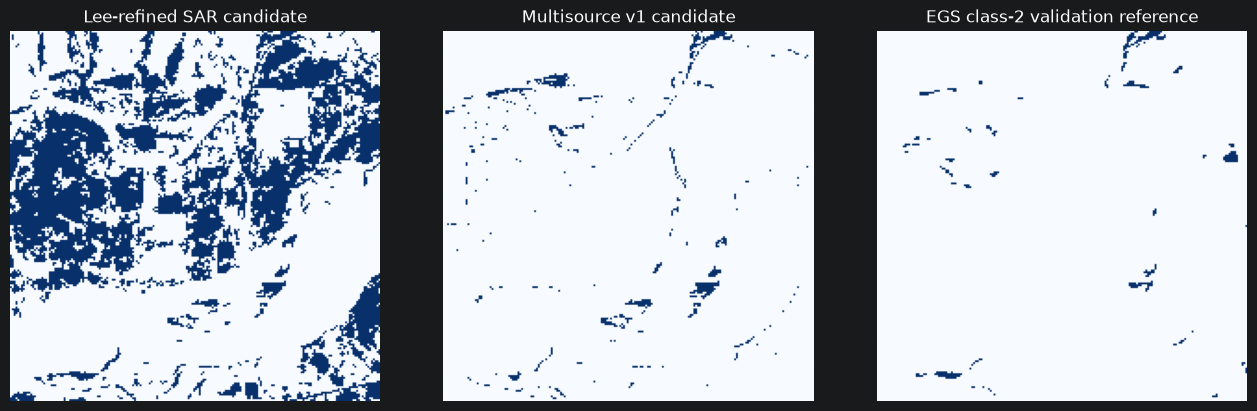

In [41]:
display(pd.read_csv(MULTI / 'multisource_fp_diagnostics.csv').query("kind == 'FP'").groupby(['diagnostic', 'category'], as_index=False)[['pixels', 'area_ha']].sum().sort_values(['diagnostic', 'area_ha'], ascending=[True, False]).head(24).round(3))
display(pd.read_csv(MULTI / 'multisource_fn_diagnostics.csv').query("kind == 'FN'").groupby(['diagnostic', 'category'], as_index=False)[['pixels', 'area_ha']].sum().sort_values(['diagnostic', 'area_ha'], ascending=[True, False]).head(24).round(3))
import matplotlib.pyplot as plt
import rasterio
from scripts.phase3b_pipeline import permanent_and_egs_masks
sid = '20251217T141634Z'
baseline_thresholds = pd.read_csv(OUT / 'validation_metrics_refinement_lee.csv').query("candidate_id == 'C0_global_hh' and representation == 'Sigma0'").set_index('observation_id')
payload = np.load(OUT / 'cache/refinement_lee' / sid / 'grid_arrays.npz')
permanent, reference = permanent_and_egs_masks('OBS05')
from analysis.water_classification import cleanup_mask
threshold = json.loads(baseline_thresholds.loc[sid, 'thresholds'])['global_hh']
baseline_mask = cleanup_mask((payload['sigma_hh_db'] < threshold) & payload['common_valid'].astype(bool) & ~permanent, payload['common_valid'].astype(bool), min_component_pixels=2)
with rasterio.open(MULTI / 'masks' / f'{sid}_phase3b_multisource_v1_flood.tif') as src:
    enhanced_mask = src.read(1).astype(bool)
fig, axes = plt.subplots(1, 3, figsize=(13, 4), constrained_layout=True)
for ax, image, title in zip(axes, [baseline_mask, enhanced_mask, reference], ['Lee-refined SAR candidate', 'Multisource v1 candidate', 'EGS class-2 validation reference']):
    ax.imshow(image, cmap='Blues', vmin=0, vmax=1)
    ax.set_title(title)
    ax.set_axis_off()
plt.show()


## 25. Multisource gate, limitations, and next-stage interface

The registered GO thresholds remain unchanged. A FAIL retains this result as an auditable experimental branch: no `method_config_v1.json`, no remaining-six-scene processing, no Sentinel-2 holdout, and no Phase 4B handoff. The method definition records the same-beam acquisition sequences and required metadata for a future, separately planned matched multi-temporal SAR change-detection study; it does not generate any such feature in this notebook.


In [42]:
multi_gate = json.loads((MULTI / 'multisource_gate.json').read_text())
future_contract = json.loads((MULTI / 'multisource_method_definition.json').read_text())['future_temporal_interface']
display(pd.Series(multi_gate))
display(pd.Series(future_contract))


status                                                                     FAIL
gate                          {'status': 'FAIL', 'reason': 'IoU below fail g...
decision                      FAIL preserves multisource v1 as an experiment...
method_config_v1_generated                                                False
remaining_six_processed                                                   False
sentinel2_holdout_run                                                     False
created_utc                                    2026-10-04T11:44:52.309536+00:00
dtype: object

status                             metadata only; no change features are generate...
required_scene_fields              [observation_id, timestamp_utc, beam_mode, mod...
candidate_same_mode_sequences      {'16M16': ['20251213T141623Z', '20251217T14163...
future_features_not_implemented    [delta Sigma0, power ratio, temporal rank, per...
dtype: object